# RAR Per-Seed Campaign — Clean Runner

Runs the RAR experiment **one seed at a time**. Each seed writes its own
`pilot_seed_<seed>.json`, so a Colab disconnect never wipes finished work.

**Key handling:** loads automatically from **Colab Secrets** (the 🔑 icon).
Secret name must be `OPENROUTER_API_KEY` with *Notebook access* ON.

**Drive backup is optional** — if mounting fails, the run continues on local disk.

**Safety guard:** if the key is ever missing, the code *raises* instead of
silently fabricating fake results.

Run cells top to bottom. Don't start the seed loop until **PRE-FLIGHT** passes.

## 1 · Clone repo & install deps

In [1]:
import os

REPO_DIR = '/content/recursive-autonomy-research'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Tahir-yamin/recursive-autonomy-research.git $REPO_DIR
else:
    !cd $REPO_DIR && git pull

os.chdir(REPO_DIR)
print('Working dir:', os.getcwd())
!pip install -q torch numpy scipy scikit-learn networkx aiohttp matplotlib

Cloning into '/content/recursive-autonomy-research'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 303 (delta 141), reused 218 (delta 63), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 6.19 MiB | 12.64 MiB/s, done.
Resolving deltas: 100% (141/141), done.
Working dir: /content/recursive-autonomy-research


## 2 · Load API key from Colab Secrets

One-time setup: 🔑 icon → **+ Add new secret** → name `OPENROUTER_API_KEY`,
paste your key, toggle **Notebook access** ON. Then just run this cell.

In [2]:
import os

key = None
try:
    from google.colab import userdata
    key = userdata.get('OPENROUTER_API_KEY')
except Exception as e:
    print('Could not read Colab Secret:', e)

if not key:
    raise ValueError(
        '\n>>> No key found. Open the 🔑 panel, add OPENROUTER_API_KEY, '
        'and turn ON Notebook access for it, then re-run this cell.'
    )

os.environ['OPENROUTER_API_KEY'] = key
os.environ['RAR_CYCLES']         = '60'
# Model is auto-detected in the PRE-FLIGHT cell (free slugs rotate often).
print(f'Key loaded (ends ...{key[-6:]})')
print('Model will be auto-selected in the PRE-FLIGHT cell.')

Key loaded (ends ...b09c3a)
Model will be auto-selected in the PRE-FLIGHT cell.


## 3 · (Optional) Mount Google Drive for backup

If mounting fails, this cell just warns and the run continues on local disk.

In [3]:
DRIVE_BACKUP = None
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BACKUP = '/content/drive/MyDrive/RAR_results'
    os.makedirs(DRIVE_BACKUP, exist_ok=True)
    print('Drive backup ON ->', DRIVE_BACKUP)
except Exception as e:
    DRIVE_BACKUP = None
    print('Drive mount skipped (continuing on local disk only):', e)

Mounted at /content/drive
Drive backup ON -> /content/drive/MyDrive/RAR_results


## 4 · PRE-FLIGHT — auto-detect a working free model

Free `:free` slugs rotate constantly on OpenRouter. This cell probes a list of
current free candidates with one tiny call each and **locks onto the first that
responds**, setting `OPENROUTER_MODEL` for the whole run.

**Do not proceed if every candidate fails** — fix the key/quota first.

In [4]:
import sys, os
os.chdir('/content/recursive-autonomy-research')
if 'run_pilot_experiment' in sys.modules:
    del sys.modules['run_pilot_experiment']
import run_pilot_experiment as rpe

# Candidate free models, in preference order. First one that answers wins.
# openai/gpt-oss-20b:free confirmed working Jun 2026 on this account; others
# returned 404 "paid only" or 429 rate-limit. Reorder/add as the free tier shifts.
CANDIDATES = [
    'openai/gpt-oss-20b:free',
    'meta-llama/llama-3.3-70b-instruct:free',
    'google/gemma-3-12b-it:free',
    'deepseek/deepseek-chat-v3:free',
    'qwen/qwen-2.5-72b-instruct:free',
]

chosen = None
for slug in CANDIDATES:
    os.environ['OPENROUTER_MODEL'] = slug
    try:
        resp = await rpe.call_llm('Reply with the single word: OK')
    except Exception as e:
        print(f'  ✗ {slug:45s} error: {str(e)[:80]}')
        continue
    if resp:
        chosen = slug
        print(f'  ✓ {slug:45s} -> {resp[:40]!r}')
        break
    else:
        print(f'  ✗ {slug:45s} empty response')

if not chosen:
    raise RuntimeError(
        '>>> PRE-FLIGHT FAILED: no candidate free model responded.\n'
        'Check key validity / daily quota, or add a known-good slug to CANDIDATES.\n'
        'Browse current free models at https://openrouter.ai/models?max_price=0'
    )

os.environ['OPENROUTER_MODEL'] = chosen
print(f'\nPRE-FLIGHT OK — using model: {chosen}')
print('This model is now locked for the whole campaign.')

  ✓ openai/gpt-oss-20b:free                       -> 'OK'

PRE-FLIGHT OK — using model: openai/gpt-oss-20b:free
This model is now locked for the whole campaign.


## 5 · Run seeds (one at a time) — choose a benchmark

Set **`DATASET`** at the top of the next cell to one of:
`manifold` (original near-chance), `digits` (real, 10-class), `synth_tuned`
(4-class, above chance), or `openml` (real tabular, default OpenML *vehicle*,
4-class — override with `os.environ['RAR_OPENML_NAME']`).

To run all benchmarks: pick a `DATASET`, run cells 5 → 6 → 7, then change
`DATASET` and repeat. Per-seed files are namespaced
(`pilot_seed_<seed>_<DATASET>.json`) so runs never collide, and completed seeds
auto-skip on resume. Cell 8 then runs the non-LLM classical baselines
(Random Search + Bayesian Optimization) on the same dataset for comparison.

In [5]:
import os, sys, shutil, glob
os.chdir('/content/recursive-autonomy-research')

# ====== CHOOSE THE BENCHMARK ======
# 'manifold' | 'digits' | 'synth_tuned' | 'openml'
DATASET = 'digits'                 # <-- change per benchmark run
os.environ['RAR_DATASET'] = DATASET
os.environ['RAR_CYCLES']  = os.environ.get('RAR_CYCLES', '60')

if not os.environ.get('OPENROUTER_API_KEY'):
    raise ValueError('Key missing — re-run the key cell.')

for mod in ('run_pilot_experiment', 'run_deep_learning_harness'):
    if mod in sys.modules:
        del sys.modules[mod]
import run_pilot_experiment as rpe   # re-imported so RAR_DATASET takes effect

# restore any already-finished seed files for THIS dataset from Drive
if DRIVE_BACKUP and os.path.exists(DRIVE_BACKUP):
    for f in glob.glob(os.path.join(DRIVE_BACKUP, f'pilot_seed_*_{DATASET}.json')):
        dst = os.path.basename(f)
        if not os.path.exists(dst):
            shutil.copy2(f, dst); print('Restored', dst, 'from Drive')

async def run_one_seed(seed):
    """Run a single seed; safe to re-run (skips if already finished)."""
    out = f'pilot_seed_{seed}_{DATASET}.json'
    if os.path.exists(out):
        print(f'Seed {seed} [{DATASET}]: already done, skipping.'); return
    print(f'===== SEED {seed} [{DATASET}] =====')
    os.environ['RAR_OUTPUT_FILE'] = out
    rpe.SEEDS = [seed]
    rpe.CYCLES = int(os.environ.get('RAR_CYCLES', '60'))
    await rpe.execute_campaign()
    if os.path.exists(out):
        print(f'Seed {seed}: DONE -> {out} ({os.path.getsize(out):,} bytes)')
        if DRIVE_BACKUP:
            shutil.copy2(out, os.path.join(DRIVE_BACKUP, out)); print('  backed up to Drive')
    else:
        print(f'WARNING: seed {seed} produced no file!')

print(f'Init OK for [{DATASET}]. Run each seed cell below one at a time;')
print('re-run only the ones interrupted — finished seeds auto-skip.')

Init OK for [digits]. Run each seed cell below one at a time;
re-run only the ones interrupted — finished seeds auto-skip.


### Per-seed cells — run one at a time
If Colab interrupts, re-run only the seed cells that did not finish; completed seeds auto-skip.

In [6]:
await run_one_seed(42)

===== SEED 42 [digits] =====

> STARTING SEED CAMPAIGN: 42
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9465 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 16} -> Val Acc: 0.8396 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9510 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.8374 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers': 

In [7]:
await run_one_seed(7)

===== SEED 7 [digits] =====

> STARTING SEED CAMPAIGN: 7
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'LeakyReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9443 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'ReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9220 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 16, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 16} -> Val Acc: 0.5924 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ELU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 32} -> Val Acc: 0.9465 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers': 1, '

In [8]:
await run_one_seed(13)

===== SEED 13 [digits] =====

> STARTING SEED CAMPAIGN: 13
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9488 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9621 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.7572 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9710 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers':

In [9]:
await run_one_seed(23)

===== SEED 23 [digits] =====

> STARTING SEED CAMPAIGN: 23
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9577 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.4744 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9488 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.8753 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers': 

In [10]:
await run_one_seed(88)

===== SEED 88 [digits] =====

> STARTING SEED CAMPAIGN: 88
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9510 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.5056 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9599 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.8530 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers': 

In [11]:
await run_one_seed(99)

===== SEED 99 [digits] =====

> STARTING SEED CAMPAIGN: 99
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ELU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9621 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'ReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9621 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 16, 'activation': 'LeakyReLU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.1759 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'LeakyReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.05, 'batch_size': 32} -> Val Acc: 0.9710 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_lay

In [12]:
await run_one_seed(101)

===== SEED 101 [digits] =====

> STARTING SEED CAMPAIGN: 101
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9532 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 16} -> Val Acc: 0.7038 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 16, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9332 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 32} -> Val Acc: 0.9555 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers':

In [13]:
await run_one_seed(107)

===== SEED 107 [digits] =====

> STARTING SEED CAMPAIGN: 107
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9644 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
Rate limited (429). Retrying after 2.25s backoff...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 16} -> Val Acc: 0.5880 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9666 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.8641 (Redundant: False)
STATELESS_B

In [14]:
await run_one_seed(113)

===== SEED 113 [digits] =====

> STARTING SEED CAMPAIGN: 113
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9510 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9421 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 64, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.7595 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 64} -> Val Acc: 0.9510 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers

In [15]:
await run_one_seed(127)

===== SEED 127 [digits] =====

> STARTING SEED CAMPAIGN: 127
STATELESS_BASELINE Cycle 1/60...
  Proposed: {'num_conv_layers': 2, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 32} -> Val Acc: 0.9644 (Redundant: False)
STATELESS_BASELINE Cycle 2/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 16} -> Val Acc: 0.9488 (Redundant: False)
STATELESS_BASELINE Cycle 3/60...
  Proposed: {'num_conv_layers': 1, 'filters_2': 16, 'activation': 'ELU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.0001, 'batch_size': 64} -> Val Acc: 0.3163 (Redundant: False)
STATELESS_BASELINE Cycle 4/60...
  Proposed: {'num_conv_layers': 3, 'filters_2': 32, 'activation': 'ReLU', 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'lr': 0.01, 'batch_size': 32} -> Val Acc: 0.9599 (Redundant: False)
STATELESS_BASELINE Cycle 5/60...
  Proposed: {'num_conv_layers

## Progress Monitoring
Use these cells while the seeds are running to track file generation and accuracy trends.

In [19]:
import os
import glob
import pandas as pd
from datetime import datetime

# Check for local files
files = glob.glob(f'pilot_seed_*_{DATASET}.json')
stats = []
for f in files:
    s = os.stat(f)
    stats.append({
        'file': f,
        'size_kb': round(s.st_size / 1024, 2),
        'last_modified': datetime.fromtimestamp(s.st_mtime).strftime('%H:%M:%S')
    })

if stats:
    print(f"Monitoring {len(stats)} seed files for dataset: {DATASET}")
    display(pd.DataFrame(stats).sort_values('file'))
else:
    print(f"No seed files found yet for {DATASET}. Check if the first seed cell is running.")

Monitoring 10 seed files for dataset: digits


,file,size_kb,last_modified
7,pilot_seed_101_digits.json,1.81,20:02:11
5,pilot_seed_107_digits.json,1.83,20:32:47
1,pilot_seed_113_digits.json,1.81,20:57:34
4,pilot_seed_127_digits.json,1.83,21:24:48
6,pilot_seed_13_digits.json,1.82,18:27:54
0,pilot_seed_23_digits.json,1.82,18:50:43
2,pilot_seed_42_digits.json,1.83,17:42:25
9,pilot_seed_7_digits.json,1.82,18:04:18
3,pilot_seed_88_digits.json,1.82,19:16:50
8,pilot_seed_99_digits.json,1.81,19:39:49


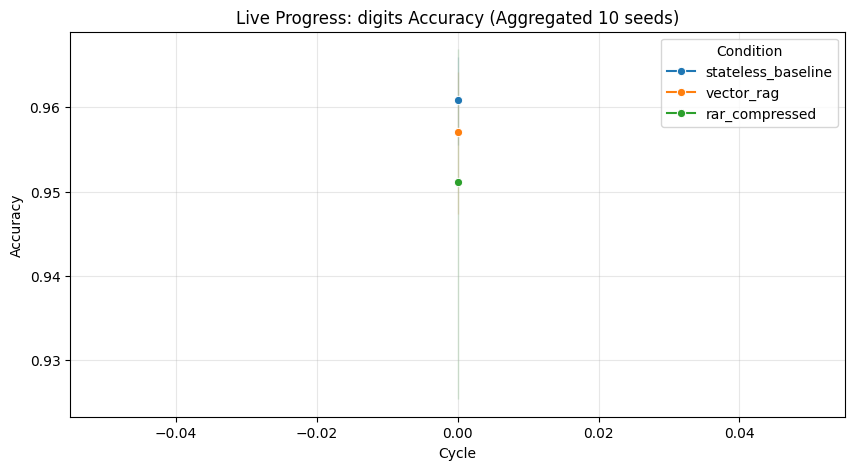

In [20]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Live plot of accuracy from available seeds
seed_files = sorted(glob.glob(f'pilot_seed_*_{DATASET}.json'))
if len(seed_files) > 0:
    all_data = []
    for f in seed_files:
        with open(f) as j:
            data = json.load(j)
            seed_num = data.get('SEEDS', [0])[0]
            for condition, details in data['data']['conditions'].items():
                accs = details.get('test_accuracies', [])
                for cycle, acc in enumerate(accs):
                    all_data.append({'Seed': seed_num, 'Condition': condition, 'Cycle': cycle, 'Accuracy': acc})

    if all_data:
        df_progress = pd.DataFrame(all_data)
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=df_progress, x='Cycle', y='Accuracy', hue='Condition', marker='o')
        plt.title(f'Live Progress: {DATASET} Accuracy (Aggregated {len(seed_files)} seeds)')
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("Waiting for at least one seed file to generate a plot...")

## 6 · Merge seeds → final pilot_results.json (real Wilcoxon p)

In [16]:
import os, glob, shutil
os.chdir('/content/recursive-autonomy-research')

# uses DATASET set in the seed-loop cell above
if DRIVE_BACKUP and os.path.exists(DRIVE_BACKUP):
    for f in glob.glob(os.path.join(DRIVE_BACKUP, f'pilot_seed_*_{DATASET}.json')):
        dst = os.path.basename(f)
        if not os.path.exists(dst):
            shutil.copy2(f, dst)

seed_files = sorted(glob.glob(f'pilot_seed_*_{DATASET}.json'))
print(f'{len(seed_files)} seed files for [{DATASET}]:', [os.path.basename(f) for f in seed_files])

if len(seed_files) < 2:
    print('Need >=2 seeds to merge.')
else:
    !python merge_seeds.py {DATASET}
    merged = f'pilot_results_{DATASET}.json'
    if DRIVE_BACKUP and os.path.exists(merged):
        shutil.copy2(merged, os.path.join(DRIVE_BACKUP, merged))
        print('Merged result backed up to Drive ->', merged)

10 seed files for [digits]: ['pilot_seed_101_digits.json', 'pilot_seed_107_digits.json', 'pilot_seed_113_digits.json', 'pilot_seed_127_digits.json', 'pilot_seed_13_digits.json', 'pilot_seed_23_digits.json', 'pilot_seed_42_digits.json', 'pilot_seed_7_digits.json', 'pilot_seed_88_digits.json', 'pilot_seed_99_digits.json']
Merged seed 7 from pilot_seed_7_digits.json
Merged seed 13 from pilot_seed_13_digits.json
Merged seed 23 from pilot_seed_23_digits.json
Merged seed 42 from pilot_seed_42_digits.json
Merged seed 88 from pilot_seed_88_digits.json
Merged seed 99 from pilot_seed_99_digits.json
Merged seed 101 from pilot_seed_101_digits.json
Merged seed 107 from pilot_seed_107_digits.json
Merged seed 113 from pilot_seed_113_digits.json
Merged seed 127 from pilot_seed_127_digits.json

Merged 10 seeds: [7, 13, 23, 42, 88, 99, 101, 107, 113, 127]

--- REAL AGGREGATE (merged) ---
stateless_baseline test_acc=0.9608  net_tokens=350248
vector_rag         test_acc=0.9571  net_tokens=170542
rar_compr

## 7 · Sanity check — the honest numbers

In [17]:
import json
with open(f'pilot_results_{DATASET}.json') as f:
    r = json.load(f)
print('Dataset:', r.get('dataset_tag'))
print('Seeds :', r['SEEDS'])
print('Cycles:', r['CYCLES'])
print('Wilcoxon p (RAR > Baseline):', r['wilcoxon_p_value_RAR_vs_Baseline'])
print()
for cond in ['stateless_baseline', 'vector_rag', 'rar_compressed']:
    d = r['data']['conditions'][cond]
    ta = d['test_accuracies']; nt = d['net_tokens']
    print(f'{cond:20s} test_acc={sum(ta)/len(ta):.4f}  net_tokens={sum(nt)/len(nt):,.0f}')

Dataset: digits
Seeds : [7, 13, 23, 42, 88, 99, 101, 107, 113, 127]
Cycles: 60
Wilcoxon p (RAR > Baseline): 0.4727

stateless_baseline   test_acc=0.9608  net_tokens=350,248
vector_rag           test_acc=0.9571  net_tokens=170,542
rar_compressed       test_acc=0.9511  net_tokens=105,839


## 8 · Classical HPO baselines (Random Search + Bayesian Optimization)

Non-LLM references on the **same** dataset and search space, so the paper can
answer "does the LLM agent beat plain random search / Bayesian optimization?"
These consume zero language-model tokens. Run after the LLM campaign for the
current `DATASET`.

In [18]:
import os, shutil
os.chdir('/content/recursive-autonomy-research')
!pip install -q optuna
os.environ['RAR_DATASET'] = DATASET            # same dataset as the LLM campaign
os.environ['RAR_CYCLES']  = os.environ.get('RAR_CYCLES', '60')

!python run_classical_baselines.py

merged = f'pilot_results_{DATASET}_classical.json'
if DRIVE_BACKUP and os.path.exists(merged):
    shutil.copy2(merged, os.path.join(DRIVE_BACKUP, merged))
    import glob
    for f in glob.glob(f'pilot_seed_*_{DATASET}_classical.json'):
        shutil.copy2(f, os.path.join(DRIVE_BACKUP, os.path.basename(f)))
    print('Classical results backed up to Drive ->', merged)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00
Classical baselines | dataset=digits cycles=60 seeds=[42, 7, 13, 23, 88, 99, 101, 107, 113, 127]
SRE Test Vault Audit: Config: {'num_conv_layers': 3, 'filters_2': 16, 'activation': 'LeakyReLU', 'dropout_rate': 0.5, 'optimizer': 'SGD', 'lr': 0.0001, 'batch_size': 16} -> Mean Test Acc: 0.3613 +/- 0.0833 across 5 initializations.
seed 42 random_search  val=0.3497 test=0.3613 redundant=59 178.5s
SRE Test Vault Audit: Config: {'num_conv_layers': 3, 'filters_2': 64, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'AdamW', 'lr': 0.001, 'batch_size': 16} -> Mean Test Acc: 0.9644 +/- 0.0051 across 5 initializations.
seed 42 bayesian_opt   val=0.9621 test=0.9644 redundant=23 200.6s
  wrote pilot_seed_42_digits_classical.json
SRE Test Vault Audit: Config: {'num_conv_layers': 1, 'filters_2': 32, 'activation': 'LeakyReLU', 'dropout_rate': 0.0, 'optimizer': 'SGD', 'lr': 0.01, 'batch_size': 16} -> Mean Test A